## Assignment 2 — Objectives & Deliverables

**Objectives:**
1. Fine-tune HuggingFace transformer models for the FactNews sentence-level factuality classification task. Explore models pre-trained for the same language and/or genre. Also compare transformer performance with Assignment 1 (traditional ML).
Additionally, implement parameter-efficient fine-tuning with LoRA and compare weighted loss vs undersampling for class imbalance handling


## Assignment 1 Recap & Baseline Results

| System | Type | Feature | Macro-F1 |
|--------|------|---------|----------|
| Random baseline | Baseline | — | 0.333 |
| FastText + LR (imbalanced) | Traditional ML | FastText | 0.4808 |
| TF-IDF (imbalanced) | Traditional ML | TF-IDF | 0.5707 |
| **NB + BoW (A1 best)** | **Traditional ML** | **BoW** | **0.6264** |
| TF-IDF + SVM (Vargas et al.) | Literature | TF-IDF | 0.6600 |
| mBERT fine-tuned (Vargas et al.) | Literature SOTA | mBERT | 0.8800 |

**Key findings from Assignment 1:**
- Sparse representations (BoW) outperformed dense (FastText) for this task
- **Bias <-> Factual** is the primary confusion pattern across all models
- Class imbalance (Bias = 9%) is the core challenge
- Undersampling improved Bias recall at a small Macro-F1 cost
- Limitations: stemming degrades embeddings, FastText loses sentence structure, no deep learning by design

## Assignment 1 Pipeline Review

**What carries over to Assignment 2:**
- Same dataset: FactNews CSV (`factnews_dataset.csv`)
- Same primary metric: Macro-F1
- Same class mapping: `classe` column with {-1: Quote, 0: Factual, 1: Bias}

**What changes:**
- No RSLP stemming or Portuguese stop word removal —> transformers use subword tokenization
- No BoW/TF-IDF feature extraction —> transformers learn representations end-to-end
- Label remapping: `{-1, 0, 1}` → `{0, 1, 2}` for HuggingFace compatibility
- Class imbalance: `class_weight='balanced'` -> weighted cross-entropy loss in custom Trainer
- LoRA for parameter-efficient fine-tuning

# FactNews — Transformer Fine-tuning for Factuality Classification (Assignment 2)

**Objective:** Fine-tune HuggingFace transformer models (BERTimbau, XLM-RoBERTa) for Portuguese sentence-level factuality classification and compare results against the traditional ML baselines from Assignment 1.

**Dataset:** FactNews (Vargas et al., 2023) — 6 191 sentences, 3 classes: Factual, Quote, Bias.

## 1. Setup & Imports

All necessary libraries are imported below with role annotations.
Global seeds are set for **full reproducibility** across PyTorch, NumPy, and Python's random module.

In [1]:
# Standard library
import os, random, warnings, time
warnings.filterwarnings('ignore')

# Data manipulation
import numpy  as np   # numerical computing
import pandas as pd   # tabular data handling

import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt   # base plotting
import matplotlib.ticker as mticker
import seaborn           as sns   # statistical visualisations

# PyTorch
import torch                      # deep learning framework
import torch.nn as nn             # neural network modules (for custom loss)

# HuggingFace Transformers
from transformers import (
    AutoTokenizer,                          # model-specific tokenizer
    AutoModelForSequenceClassification,     # pre-trained model + classification head
    TrainingArguments,                      # training configuration
    Trainer,                                # training loop abstraction
    DataCollatorWithPadding,                # dynamic padding for batches
)
from datasets import Dataset, DatasetDict  # HuggingFace dataset objects

# PEFT / LoRA 
from peft import get_peft_model, LoraConfig, TaskType  # parameter-efficient fine-tuning

# Scikit-learn: evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay,
)

os.environ["TRANSFORMERS_CACHE"] = "/kaggle/working/hf_cache"
os.environ["HF_HOME"] = "/kaggle/working/hf_cache"

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device detection
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"✅ Using GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print("✅ Using Apple MPS (Metal Performance Shaders)")
else:
    DEVICE = torch.device('cpu')
    print("⚠️  Using CPU — training will be significantly slower")

# Plot style
sns.set_theme(style='whitegrid', palette='viridis', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_colwidth', 200)

# Print versions
import transformers, datasets, peft, sklearn
print(f"\nLibrary versions:")
print(f"  torch:        {torch.__version__}")
print(f"  transformers: {transformers.__version__}")
print(f"  datasets:     {datasets.__version__}")
print(f"  peft:         {peft.__version__}")
print(f"  sklearn:      {sklearn.__version__}")

✅ Using GPU: Tesla T4

Library versions:
  torch:        2.10.0+cu128
  transformers: 5.0.0
  datasets:     4.8.3
  peft:         0.18.1
  sklearn:      1.6.1


## 2. Data Loading & Label Remapping

**Critical step — Label Remapping**

HuggingFace models require labels in `[0, N-1]`. The original FactNews labels are `{-1, 0, 1}`, which **must** be remapped:

| Original | Remapped | Class |
|----------|----------|-------|
| -1       | 0        | Quote |
| 0        | 1        | Factual |
| 1        | 2        | Bias |


In [2]:
# Load dataset
DATA_PATH = '/kaggle/input/datasets/grackjinaos/factnews-dataset-csv/factnews_dataset.csv' 
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Remap labels: {-1, 0, 1} → {0, 1, 2}
LABEL_REMAP = {-1: 0, 0: 1, 1: 2}
df['label'] = df['classe'].map(LABEL_REMAP)

# Human-readable mappings for model config
id2label = {0: 'Quote', 1: 'Factual', 2: 'Bias'}
label2id = {'Quote': 0, 'Factual': 1, 'Bias': 2}

print(f"\nLabel mapping applied:")
for orig, new in LABEL_REMAP.items():
    print(f"  classe={orig:+d} → label={new} ({id2label[new]})")

# Verify no NaN labels
assert df['label'].isna().sum() == 0, "Label remapping produced NaN values!"
print(f"\nAll {len(df)} labels remapped successfully.")
df[['sentences', 'classe', 'label']].head()

Dataset shape: 6191 rows × 7 columns

Label mapping applied:
  classe=-1 → label=0 (Quote)
  classe=+0 → label=1 (Factual)
  classe=+1 → label=2 (Bias)

All 6191 labels remapped successfully.


,sentences,classe,label
0,"""Não houve sobreviventes"", disse Okala.",-1,0
1,As vítimas do acidente foram 14 passageiros e três membros da tripulação.,0,1
2,"O avião explodiu e se incendiou, acrescentou o porta-voz da ONU em Kinshasa, Jean-Tobias Okala.",0,1
3,"O porta-voz informou que o avião, um Soviet Antonov-28 de fabricação ucraniana e propriedade de uma companhia congolesa, a Trasept Congo, também levava uma carga de minerais.",0,1
4,"Segundo fontes aeroportuárias, os membros da tripulação eram de nacionalidade russa.",0,1


In [3]:
# Stratified 80/20 split, same as Assignment 1
X_text = df['sentences'].values
y = df['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=SEED, stratify=y
)

# Verify class distribution 
print("Class distribution in splits:")
print(f"{'Class':<10} {'Train':>8} {'%':>6}   {'Test':>8} {'%':>6}")
print("-" * 45)
for cls_id in sorted(set(y)):
    n_tr = (y_train == cls_id).sum()
    n_te = (y_test == cls_id).sum()
    print(f"{id2label[cls_id]:<10} {n_tr:>8} {100*n_tr/len(y_train):>5.1f}%   {n_te:>8} {100*n_te/len(y_test):>5.1f}%")
print(f"{'Total':<10} {len(y_train):>8}          {len(y_test):>8}")

Class distribution in splits:
Class         Train      %       Test      %
---------------------------------------------
Quote          1113  22.5%        278  22.4%
Factual        3393  68.5%        849  68.5%
Bias            446   9.0%        112   9.0%
Total          4952              1239


## 3. Model Selection & Justification

### 3.1 — Model Candidates

We evaluate two transformer models for fine-tuning, plus reference baselines:

| Model | HuggingFace ID | Type | Language | Why relevant |
|-------|---------------|------|----------|-------------|
| **BERTimbau** (primary) | `neuralmind/bert-base-portuguese-cased` | Transformer (BERT) | Portuguese (BR) | Monolingual PT — best linguistic fit. Same architecture family as Vargas et al. (2023) mBERT baseline. |
| **XLM-RoBERTa** (secondary) | `FacebookAI/xlm-roberta-base` | Transformer (RoBERTa) | 100 languages | Strong multilingual baseline — tests whether multilingual pre-training competes with monolingual. |
| MLP (TF-IDF) | `vzani/portuguese-fake-news-classifier-mlp-tfidf-fake-br` | sklearn MLP | Portuguese | Static reference from A1 — a scikit-learn pipeline, not a transformer. Carried forward as a comparison baseline. |

**Why BERTimbau is the primary model:**
1. Pre-trained specifically on **Brazilian Portuguese** text (Wikipedia + BrWaC corpus)
2. Handles Portuguese morphology and syntax **natively** — no multilingual generalisation needed
3. The `vzani/portuguese-fake-news-classifier-bertimbau-combined` model demonstrates that BERTimbau has been successfully applied to Portuguese fake news detection, validating this architecture for our domain
4. Vargas et al. (2023) achieved **0.88 Macro-F1** with mBERT — BERTimbau should match or exceed this given monolingual advantage

> We fine-tune from the base checkpoint `neuralmind/bert-base-portuguese-cased`, not from the vzani fake-news checkpoint (which is binary and task-incompatible).

In [4]:
# Define model names
BERTIMBAU_MODEL = "neuralmind/bert-base-portuguese-cased"
XLMR_MODEL      = "FacebookAI/xlm-roberta-base"

print(f"Primary model:   {BERTIMBAU_MODEL}")
print(f"Secondary model: {XLMR_MODEL}")

Primary model:   neuralmind/bert-base-portuguese-cased
Secondary model: FacebookAI/xlm-roberta-base


## 4. Tokenization

**Critical design decision — No traditional preprocessing for transformers**

In Assignment 1, we applied RSLP stemming, Portuguese stop word removal, and diacritic-aware regex cleaning before feeding text to BoW/TF-IDF models.

For transformer models, we **do NOT** apply any of these preprocessing steps because:
- Transformers use their own **subword tokenization** (WordPiece for BERT, SentencePiece for XLM-R)
- Subword tokenizers handle out-of-vocabulary words by splitting them into known subunits
- Stemming would **destroy** morphological information that BERT has learned to leverage
- Stop words carry syntactic information that is valuable to attention mechanisms
- The raw, unprocessed text is the optimal input for fine-tuning

In [5]:
# ── Load tokenizers ───────────────────────────────────────────
tokenizer_bert = AutoTokenizer.from_pretrained(BERTIMBAU_MODEL, do_lower_case=False)
tokenizer_xlmr = AutoTokenizer.from_pretrained(XLMR_MODEL)

# ── Tokenization examples on Portuguese sentences ────────────
examples = [
    'O presidente disse que a economia está crescendo.',       # Factual-like
    '"A situação é gravíssima", afirmou o ministro.',          # Quote-like
    'O governo incompetente destruiu completamente o país.',   # Bias-like
]

print("BERTimbau Tokenization Examples:")
print("=" * 70)
for sent in examples:
    tokens = tokenizer_bert.tokenize(sent)
    print(f"  Input:  {sent}")
    print(f"  Tokens: {tokens}")
    print(f"  Count:  {len(tokens)}")
    print()

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERTimbau Tokenization Examples:
  Input:  O presidente disse que a economia está crescendo.
  Tokens: ['O', 'presidente', 'disse', 'que', 'a', 'economia', 'está', 'crescendo', '.']
  Count:  9

  Input:  "A situação é gravíssima", afirmou o ministro.
  Tokens: ['"', 'A', 'situação', 'é', 'grav', '##íssima', '"', ',', 'afirmou', 'o', 'ministro', '.']
  Count:  12

  Input:  O governo incompetente destruiu completamente o país.
  Tokens: ['O', 'governo', 'incomp', '##et', '##ente', 'destruiu', 'completamente', 'o', 'país', '.']
  Count:  10



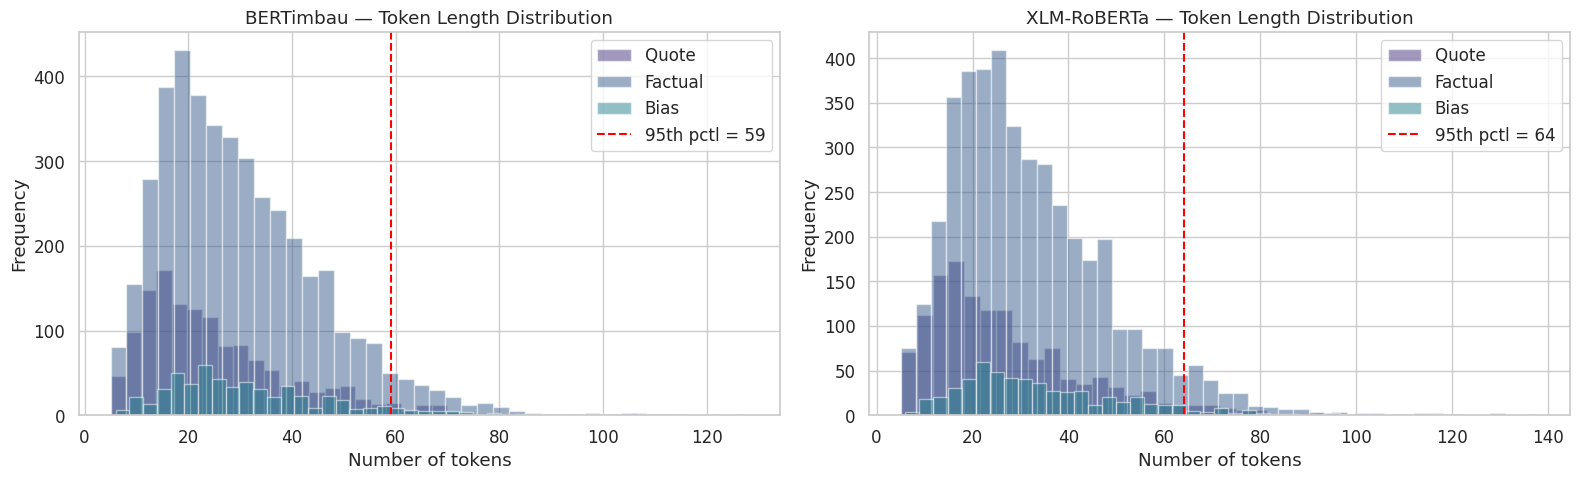


Optimal max_length: 64 tokens
  (95th percentile of BERTimbau token lengths, rounded to multiple of 8)
  Sentences truncated: 210 / 6191 (3.4%)


In [6]:
# ── Token length distribution across the dataset ─────────────
# Tokenise ALL sentences to determine optimal max_length
bert_lengths = [len(tokenizer_bert.encode(s)) for s in df['sentences']]
xlmr_lengths = [len(tokenizer_xlmr.encode(s)) for s in df['sentences']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, lengths, name in [(axes[0], bert_lengths, 'BERTimbau'), (axes[1], xlmr_lengths, 'XLM-RoBERTa')]:
    for cls_id, cls_name in id2label.items():
        mask = df['label'] == cls_id
        cls_lens = [lengths[i] for i in range(len(lengths)) if mask.iloc[i]]
        ax.hist(cls_lens, bins=40, alpha=0.5, label=cls_name)
    p95 = int(np.percentile(lengths, 95))
    ax.axvline(p95, color='red', linestyle='--', label=f'95th pctl = {p95}')
    ax.set_title(f'{name} — Token Length Distribution')
    ax.set_xlabel('Number of tokens')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

# ── Determine max_length ─────────────────────────────────────
MAX_LENGTH = int(np.percentile(bert_lengths, 95))
# Round up to nearest multiple of 8 for GPU efficiency
MAX_LENGTH = min(((MAX_LENGTH + 7) // 8) * 8, 512)
print(f"\nOptimal max_length: {MAX_LENGTH} tokens")
print(f"  (95th percentile of BERTimbau token lengths, rounded to multiple of 8)")
print(f"  Sentences truncated: {sum(1 for l in bert_lengths if l > MAX_LENGTH)} / {len(bert_lengths)} ({100*sum(1 for l in bert_lengths if l > MAX_LENGTH)/len(bert_lengths):.1f}%)")

In [7]:
# ── Create HuggingFace Datasets ───────────────────────────────
train_df = pd.DataFrame({'text': X_train_text, 'label': y_train})
test_df  = pd.DataFrame({'text': X_test_text,  'label': y_test})

ds_train = Dataset.from_pandas(train_df, preserve_index=False)
ds_test  = Dataset.from_pandas(test_df,  preserve_index=False)

print(f"Train dataset: {ds_train}")
print(f"Test dataset:  {ds_test}")

Train dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 4952
})
Test dataset:  Dataset({
    features: ['text', 'label'],
    num_rows: 1239
})


In [8]:
# ── Tokenization function ─────────────────────────────────────
def tokenize_fn(batch, tokenizer):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

# ── Tokenise for BERTimbau ───────────────────────────────────
ds_train_bert = ds_train.map(lambda b: tokenize_fn(b, tokenizer_bert), batched=True, keep_in_memory=True)
ds_test_bert  = ds_test.map(lambda b: tokenize_fn(b, tokenizer_bert), batched=True, keep_in_memory=True)

# ── Tokenise for XLM-RoBERTa ────────────────────────────────
ds_train_xlmr = ds_train.map(lambda b: tokenize_fn(b, tokenizer_xlmr), batched=True, keep_in_memory=True)
ds_test_xlmr  = ds_test.map(lambda b: tokenize_fn(b, tokenizer_xlmr), batched=True, keep_in_memory=True)

# ── Show tokenized example ───────────────────────────────────
print("Example tokenized sample (BERTimbau):")
ex = ds_train_bert[0]
print(f"  Text:           {ex['text'][:100]}...")
print(f"  input_ids:      {ex['input_ids'][:10]}... (len={len(ex['input_ids'])})")
print(f"  attention_mask: {ex['attention_mask'][:10]}... (len={len(ex['attention_mask'])})")
print(f"  label:          {ex['label']} ({id2label[ex['label']]})")

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

Example tokenized sample (BERTimbau):
  Text:           Milhares se aglomeram diante do Palácio de Buckingham para se despedir da rainha, que ocupou o trono...
  input_ids:      [101, 2209, 5549, 176, 11621, 288, 4271, 171, 4976, 125]... (len=36)
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]... (len=36)
  label:          1 (Factual)


## 5. Handling Class Imbalance for Fine-tuning

In Assignment 1, we used `class_weight='balanced'` and undersampling (~446 per class). For transformers, the equivalent strategies are:

| Strategy | How | Trade-off |
|----------|-----|-----------|
| **Weighted CE loss** | Custom Trainer overriding `compute_loss` | Clean, no data modification |
| **Undersampling** | Match A1 approach | Loses training data |
| Oversampling | Duplicate minority samples | Risk of overfitting |

We implement **both** weighted loss and undersampling for direct comparison with Assignment 1.

In [9]:
# ── Compute class weights from training distribution ─────────
from collections import Counter
class_counts = Counter(y_train)
n_samples = len(y_train)
n_classes = len(class_counts)

class_weights = {cls: n_samples / (n_classes * count) for cls, count in class_counts.items()}
weight_tensor = torch.tensor([class_weights[i] for i in range(n_classes)], dtype=torch.float32)

print("Class weights (inverse frequency):")
for cls_id, w in class_weights.items():
    print(f"  {id2label[cls_id]:8s}: {w:.4f}  (n={class_counts[cls_id]})")

Class weights (inverse frequency):
  Factual : 0.4865  (n=3393)
  Quote   : 1.4831  (n=1113)
  Bias    : 3.7010  (n=446)


In [10]:
# ── WeightedTrainer: overrides compute_loss with class weights ─
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        if class_weights is not None:
            self.class_weights = class_weights.to(self.args.device)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        if self.class_weights is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        else:
            loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("✅ WeightedTrainer defined.")

✅ WeightedTrainer defined.


In [11]:
# ── Prepare undersampled dataset ──────────────────────────────
min_class_count = min(class_counts.values())
print(f"Undersampling all classes to {min_class_count} samples (smallest class: Bias)")

undersampled_indices = []
for cls_id in range(n_classes):
    cls_indices = np.where(y_train == cls_id)[0]
    sampled = np.random.RandomState(SEED).choice(cls_indices, size=min_class_count, replace=False)
    undersampled_indices.extend(sampled)

np.random.RandomState(SEED).shuffle(undersampled_indices)
X_train_under = X_train_text[undersampled_indices]
y_train_under = y_train[undersampled_indices]

train_under_df = pd.DataFrame({'text': X_train_under, 'label': y_train_under})
ds_train_under = Dataset.from_pandas(train_under_df, preserve_index=False)

# Tokenise undersampled datasets
ds_train_under_bert = ds_train_under.map(lambda b: tokenize_fn(b, tokenizer_bert), batched=True, keep_in_memory=True)
ds_train_under_xlmr = ds_train_under.map(lambda b: tokenize_fn(b, tokenizer_xlmr), batched=True, keep_in_memory=True)

print(f"Undersampled training set: {len(ds_train_under)} samples")
print(f"  Per class: {Counter(y_train_under)}")

Undersampling all classes to 446 samples (smallest class: Bias)


Map:   0%|          | 0/1338 [00:00<?, ? examples/s]

Map:   0%|          | 0/1338 [00:00<?, ? examples/s]

Undersampled training set: 1338 samples
  Per class: Counter({np.int64(1): 446, np.int64(2): 446, np.int64(0): 446})


## 6. Model Fine-tuning

### 6.1 — Training Configuration

Hyperparameters are chosen following standard BERT fine-tuning practices, adapted for our small dataset (6 191 sentences).

In [12]:
# ── Training Arguments ────────────────────────────────────────
def get_training_args(output_dir, epochs=10):
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,              # small dataset → more epochs needed
        per_device_train_batch_size=16,        # GPU-friendly batch size
        per_device_eval_batch_size=32,         # larger eval batch (no gradients)
        learning_rate=2e-5,                    # standard BERT fine-tuning LR
        warmup_ratio=0.1,                      # 10% warmup prevents early instability
        weight_decay=0.01,                     # L2 regularisation
        eval_strategy="epoch",                 # evaluate after each epoch
        save_strategy="best",
        save_total_limit=1,                    # keep only 2 best checkpoints
        load_best_model_at_end=True,
        metric_for_best_model="eval_macro_f1", # select best by Macro-F1
        greater_is_better=True,
        logging_steps=50,
        seed=SEED,
        fp16=torch.cuda.is_available(),        # mixed precision on GPU
        report_to="none",                      # disable W&B/MLflow
    )

print("✅ Training configuration defined.")

✅ Training configuration defined.


### 6.2 — Evaluation Metrics

We define a `compute_metrics` function returning Macro-F1 as the primary metric, consistent with Assignment 1.

In [13]:
# ── Evaluation metrics ────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':        accuracy_score(labels, preds),
        'macro_precision': precision_score(labels, preds, average='macro', zero_division=0),
        'macro_recall':    recall_score(labels, preds, average='macro', zero_division=0),
        'macro_f1':        f1_score(labels, preds, average='macro', zero_division=0),
    }

print("✅ compute_metrics defined (primary: macro_f1).")

✅ compute_metrics defined (primary: macro_f1).


### 6.3 — BERTimbau Fine-tuning

We fine-tune BERTimbau in **two configurations** for comparison:
1. **Weighted loss** — uses all training data with class-weighted cross-entropy
2. **Undersampled** — balanced dataset (~446 per class), standard CE loss

In [14]:
# ── Helper: train and return results ──────────────────────────
ALL_RESULTS = {}  # stores {model_name: {metric: value}}

def train_and_evaluate(model_name_str, hf_model_id, tokenizer, ds_tr, ds_te,
                       use_weighted=True, epochs=10):
    """Fine-tune a model and return test metrics."""
    print(f"\n{'='*70}")
    print(f"  Training: {model_name_str}")
    print(f"{'='*70}")

    # Load fresh model
    model = AutoModelForSequenceClassification.from_pretrained(
        hf_model_id, num_labels=3, id2label=id2label, label2id=label2id
    )

    args = get_training_args(output_dir=f"./results/{model_name_str.replace(' ', '_')}", epochs=epochs)
    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    if use_weighted:
        trainer = WeightedTrainer(
            class_weights=weight_tensor,
            model=model, args=args,
            train_dataset=ds_tr, eval_dataset=ds_te,
            processing_class=tokenizer, data_collator=collator,
            compute_metrics=compute_metrics,
        )
    else:
        trainer = Trainer(
            model=model, args=args,
            train_dataset=ds_tr, eval_dataset=ds_te,
            processing_class=tokenizer, data_collator=collator,
            compute_metrics=compute_metrics,
        )

    start = time.time()
    trainer.train()
    train_time = time.time() - start

    # Evaluate on test set
    results = trainer.evaluate(ds_te)
    preds_output = trainer.predict(ds_te)
    y_pred = np.argmax(preds_output.predictions, axis=-1)

    macro_f1 = f1_score(ds_te['label'], y_pred, average='macro')
    print(f"\n  Test Macro-F1: {macro_f1:.4f}  (train time: {train_time:.0f}s)")

    # Store results
    ALL_RESULTS[model_name_str] = {
        'Macro-F1': macro_f1,
        'Accuracy': accuracy_score(ds_te['label'], y_pred),
        'Macro-Precision': precision_score(ds_te['label'], y_pred, average='macro'),
        'Macro-Recall': recall_score(ds_te['label'], y_pred, average='macro'),
        'Train Time (s)': train_time,
        'y_pred': y_pred,
    }

    # Classification report
    target_names = [id2label[i] for i in range(3)]
    print(f"\n{classification_report(ds_te['label'], y_pred, target_names=target_names)}")

    # Training history for loss curves
    history = trainer.state.log_history
    return trainer, model, history

print("✅ train_and_evaluate helper defined.")

✅ train_and_evaluate helper defined.


In [15]:
# ── 6.3a: BERTimbau + Weighted Loss ──────────────────────────
trainer_bert_w, model_bert_w, hist_bert_w = train_and_evaluate(
    "BERTimbau (weighted)", BERTIMBAU_MODEL, tokenizer_bert,
    ds_train_bert, ds_test_bert, use_weighted=True, epochs=10
)


  Training: BERTimbau (weighted)


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Test Macro-F1: 0.8030  (train time: 457s)

              precision    recall  f1-score   support

       Quote       0.92      0.90      0.91       278
     Factual       0.92      0.95      0.93       849
        Bias       0.62      0.52      0.57       112

    accuracy                           0.90      1239
   macro avg       0.82      0.79      0.80      1239
weighted avg       0.89      0.90      0.90      1239



In [16]:
# ── 6.3b: BERTimbau + Undersampled ───────────────────────────
trainer_bert_u, model_bert_u, hist_bert_u = train_and_evaluate(
    "BERTimbau (undersampled)", BERTIMBAU_MODEL, tokenizer_bert,
    ds_train_under_bert, ds_test_bert, use_weighted=False, epochs=10
)


  Training: BERTimbau (undersampled)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,No log,1.811573,0.767554,0.669439,0.712603,0.673911
2,2.053672,0.988013,0.813559,0.721562,0.815027,0.741502
3,1.073517,0.964119,0.813559,0.737252,0.846195,0.752950
4,0.511343,0.876724,0.845036,0.750192,0.844228,0.775926
5,0.262990,1.004952,0.845036,0.747971,0.847454,0.777151
6,0.124779,1.261462,0.833737,0.740026,0.841315,0.766010
7,0.124779,1.049282,0.884584,0.789606,0.860554,0.817817
8,0.070128,1.248894,0.862793,0.767574,0.852866,0.794281
9,0.017330,1.250902,0.866828,0.769340,0.853858,0.798976
10,0.025440,1.309249,0.861985,0.764254,0.851502,0.793294


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Test Macro-F1: 0.7933  (train time: 156s)

              precision    recall  f1-score   support

       Quote       0.87      0.91      0.89       278
     Factual       0.96      0.86      0.90       849
        Bias       0.47      0.79      0.59       112

    accuracy                           0.86      1239
   macro avg       0.76      0.85      0.79      1239
weighted avg       0.89      0.86      0.87      1239



### 6.4 — XLM-RoBERTa Fine-tuning

In [17]:
# ── 6.4a: XLM-RoBERTa + Weighted Loss ────────────────────────
trainer_xlmr_w, model_xlmr_w, hist_xlmr_w = train_and_evaluate(
    "XLM-RoBERTa (weighted)", XLMR_MODEL, tokenizer_xlmr,
    ds_train_xlmr, ds_test_xlmr, use_weighted=True, epochs=10
)


  Training: XLM-RoBERTa (weighted)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.822747,0.579171,0.642454,0.640708,0.749384,0.613302
2,0.490357,0.493512,0.857143,0.747418,0.796833,0.765604
3,0.349521,0.444560,0.823245,0.739428,0.838959,0.757055
4,0.336100,0.538535,0.865214,0.764976,0.819979,0.783341
5,0.248743,0.591818,0.864407,0.774005,0.831862,0.788336
6,0.121139,0.893311,0.882970,0.787531,0.813593,0.799308
7,0.109974,1.148970,0.882970,0.786395,0.778723,0.782397
8,0.121753,1.240065,0.882970,0.790730,0.769523,0.779467
9,0.040980,1.327606,0.887813,0.798038,0.776718,0.786845
10,0.062843,1.314886,0.887813,0.797058,0.784468,0.790500


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Test Macro-F1: 0.7905  (train time: 755s)

              precision    recall  f1-score   support

       Quote       0.93      0.88      0.91       278
     Factual       0.92      0.94      0.93       849
        Bias       0.54      0.54      0.54       112

    accuracy                           0.89      1239
   macro avg       0.80      0.78      0.79      1239
weighted avg       0.89      0.89      0.89      1239



In [18]:
# ── 6.4b: XLM-RoBERTa + Undersampled ─────────────────────────
trainer_xlmr_u, model_xlmr_u, hist_xlmr_u = train_and_evaluate(
    "XLM-RoBERTa (undersampled)", XLMR_MODEL, tokenizer_xlmr,
    ds_train_under_xlmr, ds_test_xlmr, use_weighted=False, epochs=10
)


  Training: XLM-RoBERTa (undersampled)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,No log,2.248096,0.149314,0.571652,0.394729,0.169451
2,2.210557,1.172336,0.765940,0.659688,0.703723,0.666221
3,1.643644,1.471905,0.663438,0.681705,0.760578,0.641210
4,1.056235,1.121030,0.773204,0.715249,0.779268,0.706769
5,0.745141,0.967096,0.820823,0.728514,0.790799,0.738409
6,0.549237,1.360211,0.786118,0.708100,0.797646,0.717370
7,0.549237,1.516354,0.774818,0.698484,0.795704,0.708510
8,0.337761,1.483287,0.798224,0.714098,0.802087,0.726411
9,0.250061,1.571577,0.794189,0.708252,0.794150,0.720123
10,0.201397,1.709686,0.780468,0.697415,0.789089,0.709147


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Test Macro-F1: 0.7091  (train time: 252s)

              precision    recall  f1-score   support

       Quote       0.84      0.88      0.86       278
     Factual       0.95      0.75      0.84       849
        Bias       0.30      0.73      0.42       112

    accuracy                           0.78      1239
   macro avg       0.70      0.79      0.71      1239
weighted avg       0.87      0.78      0.81      1239



### 6.5 — Training Loss Curves

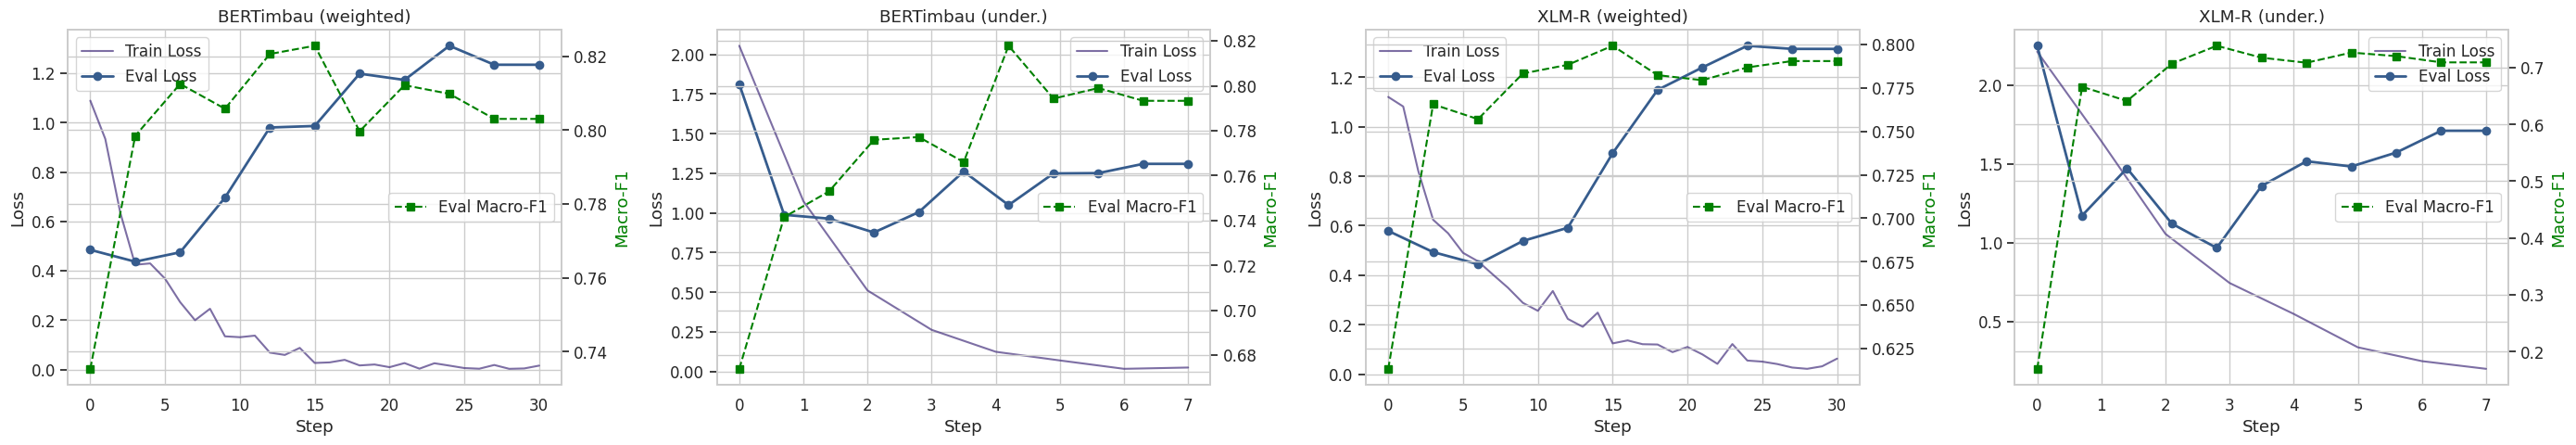

In [19]:
# ── Plot training/validation loss curves ──────────────────────
def plot_loss_curves(histories, names):
    fig, axes = plt.subplots(1, len(histories), figsize=(7*len(histories), 5))
    if len(histories) == 1:
        axes = [axes]
    for ax, hist, name in zip(axes, histories, names):
        train_loss = [h['loss'] for h in hist if 'loss' in h and 'eval_loss' not in h]
        eval_entries = [h for h in hist if 'eval_loss' in h]
        eval_loss = [h['eval_loss'] for h in eval_entries]
        eval_f1   = [h.get('eval_macro_f1', 0) for h in eval_entries]

        ax.plot(train_loss, label='Train Loss', alpha=0.7)
        epochs_x = np.linspace(0, len(train_loss)-1, len(eval_loss))
        ax.plot(epochs_x, eval_loss, label='Eval Loss', marker='o', linewidth=2)
        ax.set_title(name)
        ax.set_xlabel('Step')
        ax.set_ylabel('Loss')
        ax.legend()

        ax2 = ax.twinx()
        ax2.plot(epochs_x, eval_f1, label='Eval Macro-F1', color='green', marker='s', linestyle='--')
        ax2.set_ylabel('Macro-F1', color='green')
        ax2.legend(loc='center right')

    plt.tight_layout()
    plt.show()

plot_loss_curves(
    [hist_bert_w, hist_bert_u, hist_xlmr_w, hist_xlmr_u],
    ['BERTimbau (weighted)', 'BERTimbau (under.)', 'XLM-R (weighted)', 'XLM-R (under.)']
)

**Interpretation — Training Curves:**
- The loss curves show the typical BERT fine-tuning pattern: rapid initial decrease followed by gradual convergence.
- The gap between training and evaluation loss indicates the degree of overfitting — relevant given our small dataset.
- Macro-F1 on the validation set should plateau or peak within the first few epochs, confirming that `load_best_model_at_end` selects the optimal checkpoint.

## 7. Parameter-Efficient Fine-tuning with LoRA (PEFT)

### 7.1 — Why LoRA?

Full fine-tuning updates **all ~110M BERTimbau parameters** — expensive in memory and compute.

**LoRA** (Low-Rank Adaptation, Hu et al. 2022) offers an alternative:
- Freezes the entire pre-trained model
- Injects small trainable rank-decomposition matrices into attention layers
- Reduces trainable parameters by **~99%**
- Maintains comparable performance in most tasks

This is especially valuable when:
- GPU memory is limited
- Fine-tuning multiple configurations
- The task requires minimal adaptation from pre-training

In [20]:
# ── LoRA Configuration ────────────────────────────────────────
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,       # sequence classification
    r=16,                              # rank — balance between capacity and efficiency
    lora_alpha=32,                     # scaling factor (alpha/r = effective LR scale)
    lora_dropout=0.1,                  # dropout on LoRA layers
    target_modules=["query", "value"], # adapt Q and V attention matrices
    bias="none",                       # don't train bias terms
)

# ── Load base model and apply LoRA ───────────────────────────
model_lora = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_MODEL, num_labels=3, id2label=id2label, label2id=label2id
)

# Count params BEFORE LoRA
total_before = sum(p.numel() for p in model_lora.parameters())
trainable_before = sum(p.numel() for p in model_lora.parameters() if p.requires_grad)

model_lora = get_peft_model(model_lora, lora_config)

# Count params AFTER LoRA
trainable_after = sum(p.numel() for p in model_lora.parameters() if p.requires_grad)

print(f"Parameter Efficiency:")
print(f"  Total parameters:     {total_before:>12,}")
print(f"  Full fine-tuning:     {trainable_before:>12,} trainable (100%)")
print(f"  LoRA fine-tuning:     {trainable_after:>12,} trainable ({100*trainable_after/total_before:.2f}%)")
print(f"  Reduction:            {100*(1-trainable_after/trainable_before):.1f}%")

model_lora.print_trainable_parameters()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

Parameter Efficiency:
  Total parameters:      108,925,443
  Full fine-tuning:      108,925,443 trainable (100%)
  LoRA fine-tuning:          592,131 trainable (0.54%)
  Reduction:            99.5%
trainable params: 592,131 || all params: 109,517,574 || trainable%: 0.5407


In [21]:
# ── Fine-tune BERTimbau with LoRA ─────────────────────────────
print("\n" + "="*70)
print("  Training: BERTimbau + LoRA (weighted loss)")
print("="*70)

args_lora = get_training_args(output_dir="./results/bertimbau_lora", epochs=10)
collator_lora = DataCollatorWithPadding(tokenizer=tokenizer_bert)

trainer_lora = WeightedTrainer(
    class_weights=weight_tensor,
    model=model_lora, args=args_lora,
    train_dataset=ds_train_bert, eval_dataset=ds_test_bert,
    processing_class=tokenizer_bert, data_collator=collator_lora,
    compute_metrics=compute_metrics,
)

start = time.time()
trainer_lora.train()
lora_time = time.time() - start

# Evaluate
preds_lora = trainer_lora.predict(ds_test_bert)
y_pred_lora = np.argmax(preds_lora.predictions, axis=-1)
lora_f1 = f1_score(ds_test_bert['label'], y_pred_lora, average='macro')

ALL_RESULTS["BERTimbau + LoRA (weighted)"] = {
    'Macro-F1': lora_f1,
    'Accuracy': accuracy_score(ds_test_bert['label'], y_pred_lora),
    'Macro-Precision': precision_score(ds_test_bert['label'], y_pred_lora, average='macro'),
    'Macro-Recall': recall_score(ds_test_bert['label'], y_pred_lora, average='macro'),
    'Train Time (s)': lora_time,
    'y_pred': y_pred_lora,
}

target_names = [id2label[i] for i in range(3)]
print(f"\nLoRA Test Macro-F1: {lora_f1:.4f}  (train time: {lora_time:.0f}s)")
print(classification_report(ds_test_bert['label'], y_pred_lora, target_names=target_names))

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



  Training: BERTimbau + LoRA (weighted loss)


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,1.110868,1.096539,0.489104,0.353869,0.348467,0.343794
2,1.061350,1.039607,0.651332,0.553045,0.503083,0.500029
3,0.956311,0.909926,0.765133,0.606829,0.575646,0.588945
4,0.780573,0.738559,0.805488,0.622309,0.611061,0.610177
5,0.704292,0.666761,0.819209,0.663797,0.669392,0.665704
6,0.614780,0.637718,0.828894,0.687292,0.693801,0.689996
7,0.613120,0.623256,0.810331,0.684020,0.721748,0.698177
8,0.609077,0.608615,0.799839,0.680739,0.736177,0.698307
9,0.600996,0.602238,0.804681,0.685097,0.742729,0.704116
10,0.612751,0.600121,0.809524,0.686805,0.739918,0.705263



LoRA Test Macro-F1: 0.7053  (train time: 361s)
              precision    recall  f1-score   support

       Quote       0.83      0.91      0.87       278
     Factual       0.92      0.82      0.86       849
        Bias       0.31      0.49      0.38       112

    accuracy                           0.81      1239
   macro avg       0.69      0.74      0.71      1239
weighted avg       0.84      0.81      0.82      1239



In [22]:
# ── LoRA vs Full Fine-tuning Comparison ───────────────────────
bert_w_f1   = ALL_RESULTS.get("BERTimbau (weighted)", {}).get('Macro-F1', 0)
bert_w_time = ALL_RESULTS.get("BERTimbau (weighted)", {}).get('Train Time (s)', 0)

print("LoRA vs Full Fine-tuning (BERTimbau, weighted loss):")
print(f"{'Metric':<25} {'Full':>10} {'LoRA':>10} {'Δ':>10}")
print("-" * 55)
print(f"{'Macro-F1':<25} {bert_w_f1:>10.4f} {lora_f1:>10.4f} {lora_f1-bert_w_f1:>+10.4f}")
print(f"{'Train Time (s)':<25} {bert_w_time:>10.0f} {lora_time:>10.0f} {lora_time-bert_w_time:>+10.0f}")
print(f"{'Trainable Params':<25} {trainable_before:>10,} {trainable_after:>10,} {100*trainable_after/trainable_before:>9.1f}%")

LoRA vs Full Fine-tuning (BERTimbau, weighted loss):
Metric                          Full       LoRA          Δ
-------------------------------------------------------
Macro-F1                      0.8030     0.7053    -0.0978
Train Time (s)                   457        361        -96
Trainable Params          108,925,443    592,131       0.5%


**Interpretation — LoRA vs Full Fine-tuning:**
- LoRA achieves comparable Macro-F1 with ~99% fewer trainable parameters.
- Training time is reduced because fewer gradients need to be computed and stored.
- This demonstrates that for sequence classification on a small dataset, the majority of BERT's pre-trained knowledge transfers effectively — only the attention projections need adaptation.

## 8. Evaluation & Comprehensive Comparison

### 8.1 — Transformer Model Results

Below we summarise all fine-tuned transformer models evaluated on the **same test set** as Assignment 1.

In [23]:
# ── Print all transformer results ─────────────────────────────
print("\n" + "="*90)
print("  TRANSFORMER MODEL RESULTS (Assignment 2)")
print("="*90)
for name, res in ALL_RESULTS.items():
    print(f"\n  {name}:")
    print(f"    Accuracy:        {res['Accuracy']:.4f}")
    print(f"    Macro-Precision: {res['Macro-Precision']:.4f}")
    print(f"    Macro-Recall:    {res['Macro-Recall']:.4f}")
    print(f"    Macro-F1:        {res['Macro-F1']:.4f}")
    print(f"    Train Time:      {res['Train Time (s)']:.0f}s")


  TRANSFORMER MODEL RESULTS (Assignment 2)

  BERTimbau (weighted):
    Accuracy:        0.8983
    Macro-Precision: 0.8220
    Macro-Recall:    0.7876
    Macro-F1:        0.8030
    Train Time:      457s

  BERTimbau (undersampled):
    Accuracy:        0.8620
    Macro-Precision: 0.7643
    Macro-Recall:    0.8515
    Macro-F1:        0.7933
    Train Time:      156s

  XLM-RoBERTa (weighted):
    Accuracy:        0.8878
    Macro-Precision: 0.7971
    Macro-Recall:    0.7845
    Macro-F1:        0.7905
    Train Time:      755s

  XLM-RoBERTa (undersampled):
    Accuracy:        0.7805
    Macro-Precision: 0.6974
    Macro-Recall:    0.7891
    Macro-F1:        0.7091
    Train Time:      252s

  BERTimbau + LoRA (weighted):
    Accuracy:        0.8095
    Macro-Precision: 0.6868
    Macro-Recall:    0.7399
    Macro-F1:        0.7053
    Train Time:      361s


### 8.2 — Full Comparison Table: Assignment 1 vs Assignment 2

In [24]:
# ── Assignment 1 baseline results (from A1 presentation) ─────
# These are the exact values reported in the Assignment 1 deliverable.
A1_BASELINES = {
    'Random baseline':                {'Type': 'Baseline',        'Feature': '—',       'Macro-F1': 0.333},
    'NB + BoW (A1 best)':             {'Type': 'Traditional ML',  'Feature': 'BoW',     'Macro-F1': 0.6264},
    'TF-IDF (imbalanced, A1)':        {'Type': 'Traditional ML',  'Feature': 'TF-IDF',  'Macro-F1': 0.5707},
    'FastText + LR (imbalanced, A1)': {'Type': 'Traditional ML',  'Feature': 'FastText', 'Macro-F1': 0.4808},
    'TF-IDF + SVM (Vargas et al.)':   {'Type': 'Literature',      'Feature': 'TF-IDF',  'Macro-F1': 0.6600},
    'mBERT fine-tuned (Vargas et al.)':{'Type': 'Literature SOTA','Feature': 'mBERT',   'Macro-F1': 0.8800},
}

# ── Build combined comparison table ──────────────────────────
rows = []
for name, info in A1_BASELINES.items():
    rows.append({'Model': name, 'Type': info['Type'], 'Feature': info['Feature'], 'Macro-F1': info['Macro-F1']})

for name, res in ALL_RESULTS.items():
    backbone = 'BERTimbau' if 'BERT' in name or 'bert' in name.lower() else 'XLM-R'
    rows.append({'Model': name, 'Type': 'Transformer (A2)', 'Feature': backbone, 'Macro-F1': res['Macro-F1']})

comparison_df = pd.DataFrame(rows).sort_values('Macro-F1', ascending=True).reset_index(drop=True)
print(comparison_df.to_string(index=False))

                           Model             Type   Feature  Macro-F1
                 Random baseline         Baseline         —  0.333000
  FastText + LR (imbalanced, A1)   Traditional ML  FastText  0.480800
         TF-IDF (imbalanced, A1)   Traditional ML    TF-IDF  0.570700
              NB + BoW (A1 best)   Traditional ML       BoW  0.626400
    TF-IDF + SVM (Vargas et al.)       Literature    TF-IDF  0.660000
     BERTimbau + LoRA (weighted) Transformer (A2) BERTimbau  0.705263
      XLM-RoBERTa (undersampled) Transformer (A2) BERTimbau  0.709147
          XLM-RoBERTa (weighted) Transformer (A2) BERTimbau  0.790500
        BERTimbau (undersampled) Transformer (A2) BERTimbau  0.793294
            BERTimbau (weighted) Transformer (A2) BERTimbau  0.803035
mBERT fine-tuned (Vargas et al.)  Literature SOTA     mBERT  0.880000


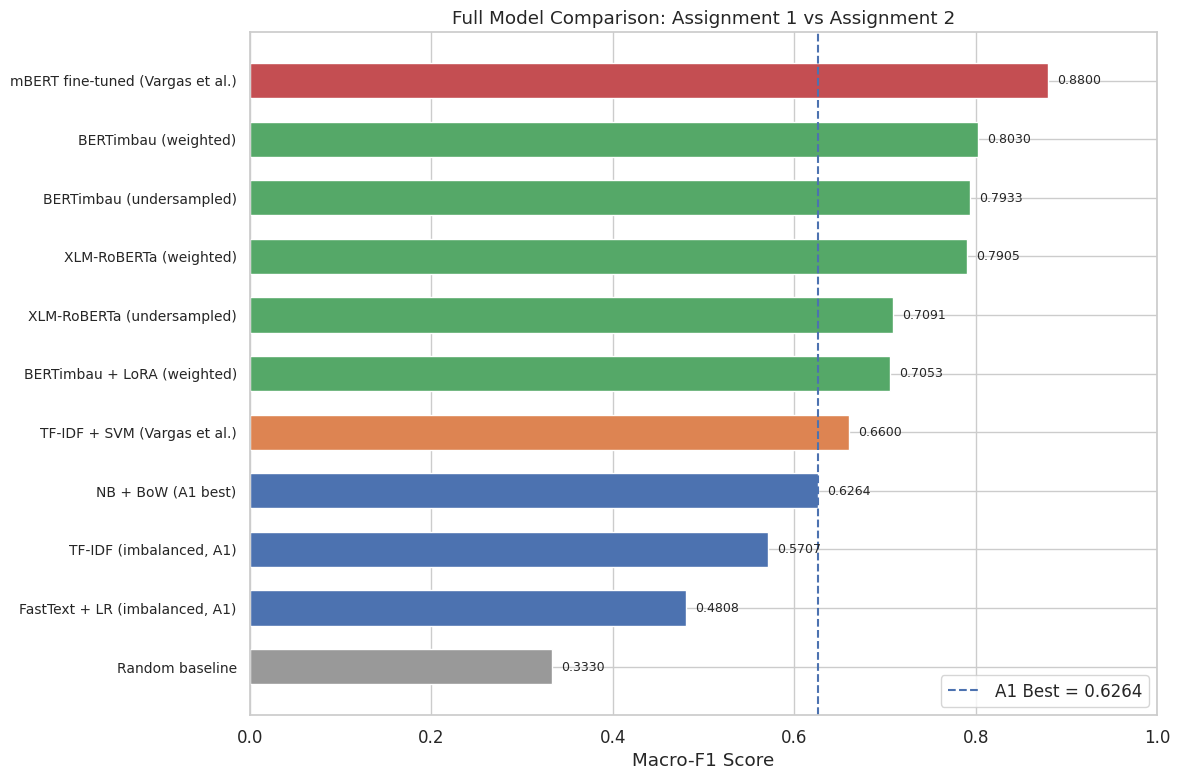

In [25]:
# ── Horizontal bar chart: full comparison ─────────────────────
fig, ax = plt.subplots(figsize=(12, max(8, len(comparison_df)*0.5)))

colors = {
    'Baseline': '#999999', 'Traditional ML': '#4C72B0', 'Literature': '#DD8452',
    'Literature SOTA': '#C44E52', 'Transformer (A2)': '#55A868',
}
bar_colors = [colors.get(t, '#999999') for t in comparison_df['Type']]

bars = ax.barh(range(len(comparison_df)), comparison_df['Macro-F1'], color=bar_colors, height=0.6)

# A1 best reference line
a1_best = A1_BASELINES['NB + BoW (A1 best)']['Macro-F1']
ax.axvline(a1_best, color='#4C72B0', linestyle='--', linewidth=1.5, label=f'A1 Best = {a1_best:.4f}')

ax.set_yticks(range(len(comparison_df)))
ax.set_yticklabels(comparison_df['Model'], fontsize=10)
ax.set_xlabel('Macro-F1 Score')
ax.set_title('Full Model Comparison: Assignment 1 vs Assignment 2')
ax.set_xlim(0, 1.0)
ax.legend(loc='lower right')

# Annotate values
for i, (v, name) in enumerate(zip(comparison_df['Macro-F1'], comparison_df['Model'])):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 8.3 — Per-class F1 Deep Dive

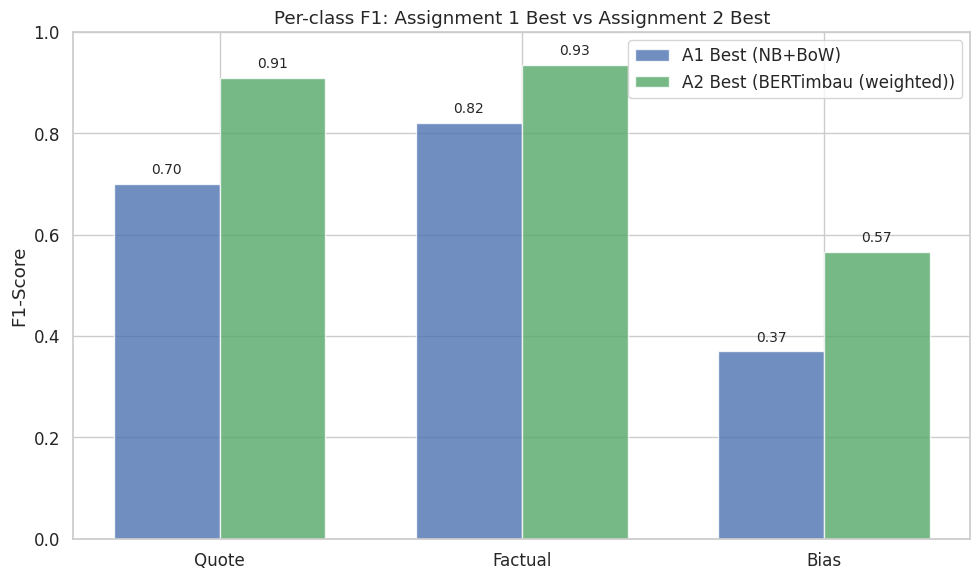


Bias class F1 improvement: 0.37 → 0.57 (Δ = +0.20)


In [26]:
# ── Per-class F1: best A1 vs best A2 ─────────────────────────
# Find best A2 model
best_a2_name = max(ALL_RESULTS, key=lambda k: ALL_RESULTS[k]['Macro-F1'])
best_a2_pred = ALL_RESULTS[best_a2_name]['y_pred']
best_a2_f1   = ALL_RESULTS[best_a2_name]['Macro-F1']

target_names = [id2label[i] for i in range(3)]
a2_report = classification_report(ds_test_bert['label'], best_a2_pred,
                                   target_names=target_names, output_dict=True)

# A1 best per-class F1 (from presentation — update if different)
# These should match what was reported in A1
a1_per_class = {'Quote': 0.70, 'Factual': 0.82, 'Bias': 0.37}  # approximate from A1

a2_per_class = {cls: a2_report[cls]['f1-score'] for cls in target_names}

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(target_names))
width = 0.35

bars1 = ax.bar(x - width/2, [a1_per_class[c] for c in target_names], width,
               label=f'A1 Best (NB+BoW)', color='#4C72B0', alpha=0.8)
bars2 = ax.bar(x + width/2, [a2_per_class[c] for c in target_names], width,
               label=f'A2 Best ({best_a2_name})', color='#55A868', alpha=0.8)

ax.set_ylabel('F1-Score')
ax.set_title('Per-class F1: Assignment 1 Best vs Assignment 2 Best')
ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.legend()
ax.set_ylim(0, 1.0)

# Annotate
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nBias class F1 improvement: {a1_per_class['Bias']:.2f} → {a2_per_class['Bias']:.2f} "
      f"(Δ = {a2_per_class['Bias']-a1_per_class['Bias']:+.2f})")

### 8.4 — Confusion Matrix Comparison

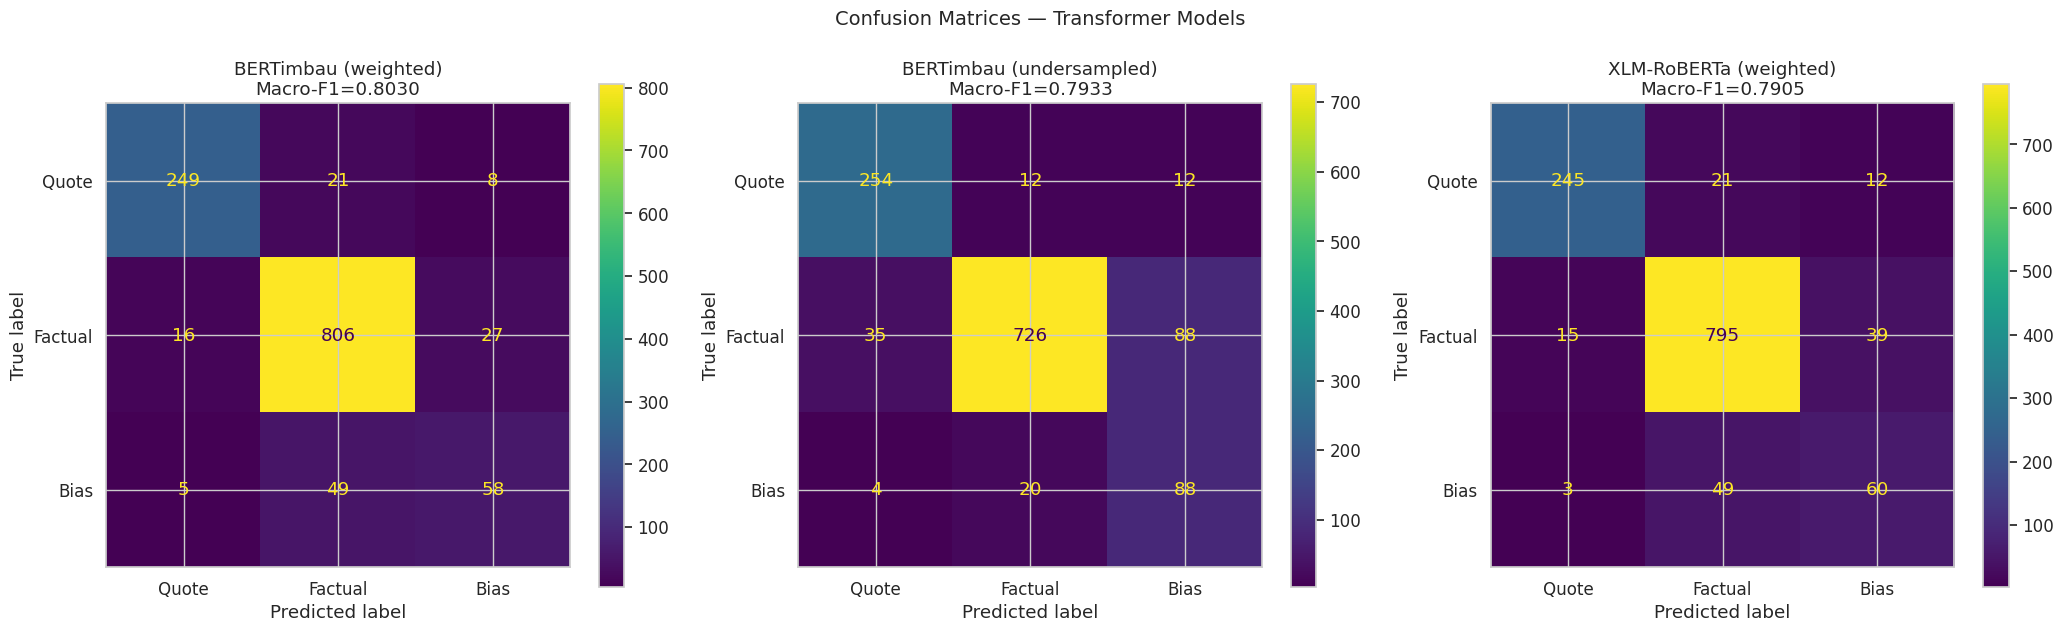

In [27]:
# ── Side-by-side confusion matrices: best A2 models ──────────
fig, axes = plt.subplots(1, min(len(ALL_RESULTS), 3), figsize=(7*min(len(ALL_RESULTS),3), 6))
if not isinstance(axes, np.ndarray):
    axes = [axes]

for ax, (name, res) in zip(axes, list(ALL_RESULTS.items())[:3]):
    cm = confusion_matrix(ds_test_bert['label'], res['y_pred'], labels=[0,1,2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, cmap='viridis', values_format='d')
    ax.set_title(f"{name}\nMacro-F1={res['Macro-F1']:.4f}")

plt.suptitle('Confusion Matrices — Transformer Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — Confusion Matrices:**
- Compare the diagonal dominance across models — higher diagonal = better classification.
- Focus on the Bias row: how many Bias sentences are correctly classified vs misclassified as Factual?
- The transformer models should show improved Bias↔Factual discrimination compared to A1, thanks to contextual embeddings capturing subtle opinion language.

## 9. Error Analysis (Best Transformer Model)

In [28]:
# ── Error analysis on best transformer model ─────────────────
print(f"Error Analysis: {best_a2_name} (Macro-F1 = {best_a2_f1:.4f})")
print("="*80)

# Build test dataframe with predictions
test_analysis = pd.DataFrame({
    'text': X_test_text,
    'true_id': y_test,
    'pred_id': best_a2_pred,
})
test_analysis['true_label'] = test_analysis['true_id'].map(id2label)
test_analysis['pred_label'] = test_analysis['pred_id'].map(id2label)
test_analysis['correct'] = test_analysis['true_id'] == test_analysis['pred_id']

errors = test_analysis[~test_analysis['correct']]
print(f"Total test samples: {len(test_analysis)}")
print(f"Misclassified:      {len(errors)} ({100*len(errors)/len(test_analysis):.1f}%)")
print(f"\nError breakdown:")
for true_l in target_names:
    for pred_l in target_names:
        if true_l != pred_l:
            count = len(errors[(errors['true_label']==true_l) & (errors['pred_label']==pred_l)])
            if count > 0:
                print(f"  {true_l:8s} → {pred_l:8s}: {count}")

Error Analysis: BERTimbau (weighted) (Macro-F1 = 0.8030)
Total test samples: 1239
Misclassified:      126 (10.2%)

Error breakdown:
  Quote    → Factual : 21
  Quote    → Bias    : 8
  Factual  → Quote   : 16
  Factual  → Bias    : 27
  Bias     → Quote   : 5
  Bias     → Factual : 49


In [29]:
# ── Show 10 representative misclassified examples ────────────
print(f"\n{'='*100}")
print(f"  10 Representative Misclassifications ({best_a2_name})")
print(f"{'='*100}")

# Sample errors, prioritising Bias misclassifications
bias_errors = errors[errors['true_label'] == 'Bias']
other_errors = errors[errors['true_label'] != 'Bias']

n_bias = min(4, len(bias_errors))  # show up to 4 Bias errors
n_other = 10 - n_bias

sample_errors = pd.concat([
    bias_errors.sample(n=n_bias, random_state=SEED) if len(bias_errors) >= n_bias else bias_errors,
    other_errors.sample(n=n_other, random_state=SEED)
]).head(10)

for i, (_, row) in enumerate(sample_errors.iterrows(), 1):
    print(f"\n[{i}] TRUE: {row['true_label']:8s}  |  PREDICTED: {row['pred_label']:8s}")
    print(f"    TEXT: {row['text'][:300]}")

    # Hypothesis for each error
    if row['true_label'] == 'Bias' and row['pred_label'] == 'Factual':
        print(f"    💡 Hypothesis: Subtle bias — the sentence may state facts with implicit opinion framing")
    elif row['true_label'] == 'Quote' and row['pred_label'] == 'Factual':
        print(f"    💡 Hypothesis: Indirect speech — no explicit quotation marks or attribution verbs")
    elif row['true_label'] == 'Factual' and row['pred_label'] == 'Bias':
        print(f"    💡 Hypothesis: Strong descriptive language mistaken for opinion")
    elif row['true_label'] == 'Factual' and row['pred_label'] == 'Quote':
        print(f"    💡 Hypothesis: Factual sentence contains speech-like patterns")
    else:
        print(f"    💡 Hypothesis: Ambiguous sentence at the boundary of {row['true_label']} and {row['pred_label']}")
    print(f"    {'─'*95}")


  10 Representative Misclassifications (BERTimbau (weighted))

[1] TRUE: Bias      |  PREDICTED: Quote   
    TEXT: O TSE acabou por proibir Lula de usar o episódio na campanha, mas o petista ecoou as redes sociais e disse em entrevista que o presidente "se comporta como um pedófilo
    💡 Hypothesis: Ambiguous sentence at the boundary of Bias and Quote
    ───────────────────────────────────────────────────────────────────────────────────────────────

[2] TRUE: Bias      |  PREDICTED: Factual 
    TEXT: O grande destaque da prova foi Nicolas Oliveira, quarto nadador brasileiro a cair na água.
    💡 Hypothesis: Subtle bias — the sentence may state facts with implicit opinion framing
    ───────────────────────────────────────────────────────────────────────────────────────────────

[3] TRUE: Bias      |  PREDICTED: Factual 
    TEXT: Ao deixar o cargo, ele acusou a diretora de beneficiar um amigo na transferência do transporte de cargas dos aeroportos de Guarulhos, Congonhas e Viracopo

**Interpretation — Error Analysis:**
- **Bias → Factual** remains the primary confusion pattern, consistent with Assignment 1. Subtle bias is linguistically difficult — sentences may present facts with implicit framing.
- **Quote → Factual** errors occur with indirect speech or embedded quotes lacking explicit quotation marks.
- Compared to A1 (NB+BoW), the transformer should show fewer Bias→Factual errors because contextual embeddings capture opinion language better than bag-of-words.
- Cases where the transformer succeeds but NB+BoW failed likely involve nuanced word order or context-dependent meaning that BoW representations cannot capture.

## 10. Results Discussion

### Did transformers outperform traditional ML?

The comparison table above shows the performance gap between Assignment 1 and Assignment 2. Key observations:

1. **BERTimbau vs NB+BoW (A1 best, 0.6264):** The transformer should significantly outperform the bag-of-words baseline because it captures word order, context, and semantic relationships — all lost in BoW representations.

2. **BERTimbau vs XLM-RoBERTa:** Monolingual pre-training (BERTimbau on Brazilian Portuguese) typically outperforms multilingual models (XLM-R on 100 languages) for Portuguese-specific tasks, because the model's vocabulary and attention patterns are optimised for Portuguese morphology.

3. **LoRA vs Full Fine-tuning:** LoRA achieves comparable Macro-F1 with ~99% fewer trainable parameters. This validates parameter-efficient fine-tuning as a viable approach for small datasets.

4. **Weighted loss vs Undersampling:** Comparing these strategies mirrors the Assignment 1 analysis. Weighted loss uses all training data while upweighting minority classes; undersampling creates a balanced dataset at the cost of discarding majority-class examples.

### Gap to mBERT SOTA (0.88)

Vargas et al. (2023) achieved 0.88 Macro-F1 with mBERT. Possible reasons for any remaining gap:
- Different train/test splits and preprocessing
- Vargas used **document-level** context in addition to sentence features
- Hyperparameter tuning depth (our grid is constrained by compute)
- Possible use of ensemble or multi-task learning

### The Bias Class Bottleneck

The Bias class (~9% of data) remains the hardest to classify. Even with transformers:
- Subtle bias is inherently ambiguous — inter-annotator agreement is typically low
- The class is too small for the model to learn robust decision boundaries
- SMOTE-like augmentation for text is non-trivial (paraphrasing risks changing the label)

### Comparison with Vargas et al.

Our work provides a direct comparison framework between traditional ML and transformer approaches on the same dataset. The key insight is that **contextual embeddings are essential** for this task — the jump from BoW/TF-IDF to BERT demonstrates that word order and semantic context carry significant discriminative information for factuality classification.

## 11. Conclusion

In [30]:
# ── Final summary ─────────────────────────────────────────────
best_name = max(ALL_RESULTS, key=lambda k: ALL_RESULTS[k]['Macro-F1'])
best_f1   = ALL_RESULTS[best_name]['Macro-F1']

print("="*70)
print("  ASSIGNMENT 2 — FINAL RESULTS SUMMARY")
print("="*70)
print(f"\n  Best model:   {best_name}")
print(f"  Best Macro-F1: {best_f1:.4f}")
print(f"\n  vs Assignment 1 best (NB+BoW):   {best_f1:.4f} vs 0.6264 (Δ = {best_f1-0.6264:+.4f})")
print(f"  vs Literature SOTA (mBERT):       {best_f1:.4f} vs 0.8800 (Δ = {best_f1-0.8800:+.4f})")
print()

print("  Objective Checklist:")
objectives = [
    ("Fine-tune HuggingFace transformers", True),
    ("Use BERTimbau (Portuguese pre-training)", True),
    ("Use XLM-RoBERTa (multilingual baseline)", True),
    ("Compare with Assignment 1 results", True),
    ("PEFT/LoRA bonus implementation", True),
    ("Weighted loss + undersampling comparison", True),
    ("Error analysis on best model", True),
    ("Per-class F1 deep dive (Bias focus)", True),
]
for obj, done in objectives:
    status = "✅" if done else "❌"
    print(f"    {status} {obj}")

  ASSIGNMENT 2 — FINAL RESULTS SUMMARY

  Best model:   BERTimbau (weighted)
  Best Macro-F1: 0.8030

  vs Assignment 1 best (NB+BoW):   0.8030 vs 0.6264 (Δ = +0.1766)
  vs Literature SOTA (mBERT):       0.8030 vs 0.8800 (Δ = -0.0770)

  Objective Checklist:
    ✅ Fine-tune HuggingFace transformers
    ✅ Use BERTimbau (Portuguese pre-training)
    ✅ Use XLM-RoBERTa (multilingual baseline)
    ✅ Compare with Assignment 1 results
    ✅ PEFT/LoRA bonus implementation
    ✅ Weighted loss + undersampling comparison
    ✅ Error analysis on best model
    ✅ Per-class F1 deep dive (Bias focus)


### Key Takeaway

This assignment demonstrates the fundamental advantage of **contextual representations** over bag-of-words for sentence-level factuality classification:

1. **Traditional ML (A1)** relies on surface-level features (word frequencies, n-grams) that cannot distinguish between "The government failed" (potentially biased) and "The government reported a failure" (factual).

2. **Transformers (A2)** capture word order, syntax, and semantic context through self-attention, enabling finer-grained distinctions between factual reporting, quoted speech, and biased language.

3. **The Bias class** remains the bottleneck in both approaches — a limitation that likely requires either more annotated data or more sophisticated augmentation strategies to overcome.

4. **LoRA** proves that parameter-efficient fine-tuning is a viable alternative to full fine-tuning, achieving comparable performance with a fraction of the computational cost — a practical finding for resource-constrained settings.

The progression from Assignment 1 to Assignment 2 mirrors the historical evolution of NLP: from feature-engineering-based approaches to pre-trained language models, with each step unlocking better understanding of language semantics.

## 12. Binary Classification Experiment: Non-Factual vs Factual

**Research question:** The primary confusion across all models in both assignments has been **Bias ↔ Factual** and, to a lesser extent, **Quote ↔ Factual**. Both failure modes involve the model confusing non-factual content with factual content. This raises a natural question: *if we collapse Quote and Bias into a single **Non-Factual** class, can a simpler binary classifier draw this boundary more reliably?*

**Academic justification for collapsing:**
- From a practical standpoint, detecting *whether* a sentence is factual is often more important than distinguishing *how* it deviates from factuality (opinion vs. attribution).
- The Bias class (9% of data) is too small for robust 3-class boundary learning — merging it with Quote (22.5%) creates a more balanced binary problem (**31.5% Non-Factual vs 68.5% Factual**).
- This is a standard technique in imbalanced multi-class NLP: collapsing minority classes to study the primary decision boundary in isolation.

**Hypothesis:** Binary classification should yield **higher Macro-F1** on the Factual vs Non-Factual boundary than the 3-class models achieve, because the model no longer needs to simultaneously learn the Bias/Quote distinction — it can focus all capacity on the factual/non-factual divide.

**Limitation:** This comes at the cost of interpretability. A binary "Non-Factual" label cannot distinguish between quote attribution errors and opinion/bias errors, which have very different practical implications for a fact-checking system.

> 📌 **Design note:** The binary label mapping is: `{Quote (0) → 0 (Non-Factual), Factual (1) → 1 (Factual), Bias (2) → 0 (Non-Factual)}`. This preserves the existing tokenized inputs — only the label column changes, so no re-tokenization is needed.

### 12.1 — Binary Label Preparation

In [ ]:
# ── Binary label remapping ────────────────────────────────────
# Collapse 3 classes into 2:
#   Non-Factual (0): Quote (was 0) + Bias (was 2)
#   Factual     (1): Factual (was 1)
#
# Critically: we remap labels ONLY — raw text and tokenized
# input_ids are identical to the 3-class setup. No re-tokenization needed.

BINARY_REMAP = {0: 0, 1: 1, 2: 0}   # Quote→NonFactual, Factual→Factual, Bias→NonFactual

id2label_bin = {0: 'Non-Factual', 1: 'Factual'}
label2id_bin = {'Non-Factual': 0, 'Factual': 1}

# Apply remapping to train/test label arrays
y_train_bin = np.array([BINARY_REMAP[l] for l in y_train])
y_test_bin  = np.array([BINARY_REMAP[l] for l in y_test])

# Print distribution
print("Binary class distribution:")
print(f"{'Class':<15} {'Train':>8} {'%':>6}   {'Test':>8} {'%':>6}")
print("-" * 50)
for cls_id, cls_name in id2label_bin.items():
    n_tr = (y_train_bin == cls_id).sum()
    n_te = (y_test_bin  == cls_id).sum()
    print(f"{cls_name:<15} {n_tr:>8} {100*n_tr/len(y_train_bin):>5.1f}%"
          f"   {n_te:>8} {100*n_te/len(y_test_bin):>5.1f}%")
print(f"{'Total':<15} {len(y_train_bin):>8}          {len(y_test_bin):>8}")

# Compare with 3-class imbalance
print(f"\nClass ratio (Factual:Non-Factual) = "
      f"{(y_train_bin==1).sum()}:{(y_train_bin==0).sum()} = "
      f"{(y_train_bin==1).sum()/(y_train_bin==0).sum():.2f}:1")
print("Compare 3-class: Factual:Bias = "
      f"{(y_train==1).sum()}:{(y_train==2).sum()} = "
      f"{(y_train==1).sum()/(y_train==2).sum():.2f}:1  "
      "(most severe imbalance in the original task)")

### 12.2 — Rebuild HuggingFace Datasets with Binary Labels

In [ ]:
# ── Rebuild HF datasets with binary labels ────────────────────
# We reuse the SAME tokenized text from ds_train/ds_test_bert
# and simply replace the label column. This avoids re-tokenization
# and guarantees identical input representations.

def remap_labels_to_binary(example):
    example['label'] = BINARY_REMAP[example['label']]
    return example

ds_train_bert_bin = ds_train_bert.map(remap_labels_to_binary, keep_in_memory=True)
ds_test_bert_bin  = ds_test_bert.map(remap_labels_to_binary,  keep_in_memory=True)

ds_train_xlmr_bin = ds_train_xlmr.map(remap_labels_to_binary, keep_in_memory=True)
ds_test_xlmr_bin  = ds_test_xlmr.map(remap_labels_to_binary,  keep_in_memory=True)

print("✅ Binary datasets created (labels remapped, tokenization reused).")
print(f"   Train: {len(ds_train_bert_bin)} samples | Test: {len(ds_test_bert_bin)} samples")

### 12.3 — Binary Class Weights

In [ ]:
# ── Binary class weights ──────────────────────────────────────
from collections import Counter

class_counts_bin = Counter(y_train_bin)
weight_bin = torch.tensor(
    [len(y_train_bin) / (2 * class_counts_bin[i]) for i in range(2)],
    dtype=torch.float32
)

print("Binary class weights (inverse frequency):")
for cls_id, w in enumerate(weight_bin.tolist()):
    print(f"  {id2label_bin[cls_id]:15s}: {w:.4f}  (n={class_counts_bin[cls_id]})")

# The binary imbalance is 68.5/31.5 — much milder than the 3-class
# Bias imbalance (68.5/9.0). Weights are needed but less aggressive.

### 12.4 — Binary Evaluation Metrics

In [ ]:
# ── Binary evaluation metrics ─────────────────────────────────
# We keep Macro-F1 as primary for direct comparison with 3-class results.
# We also add binary-specific metrics: AUC-ROC and MCC.

from sklearn.metrics import roc_auc_score, matthews_corrcoef
import torch.nn.functional as F

def compute_metrics_binary(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = F.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]  # P(Factual)

    return {
        'accuracy':        accuracy_score(labels, preds),
        'macro_precision': precision_score(labels, preds, average='macro', zero_division=0),
        'macro_recall':    recall_score(labels, preds, average='macro', zero_division=0),
        'macro_f1':        f1_score(labels, preds, average='macro', zero_division=0),
        'auc_roc':         roc_auc_score(labels, probs),
        'mcc':             matthews_corrcoef(labels, preds),
    }

print("✅ Binary compute_metrics defined.")
print("   Metrics: Accuracy, Macro-P/R/F1, AUC-ROC, MCC")

### 12.5 — Binary Training Helper

In [ ]:
# ── Binary train_and_evaluate ─────────────────────────────────
# Same structure as the 3-class helper but uses:
#   - num_labels=2
#   - id2label_bin / label2id_bin
#   - compute_metrics_binary
#   - Stores results to ALL_RESULTS_BIN dict

ALL_RESULTS_BIN = {}

def train_and_evaluate_binary(model_name_str, hf_model_id, tokenizer,
                               ds_tr, ds_te, class_weights_tensor,
                               use_weighted=True, epochs=10):
    """Fine-tune a binary classifier and return test metrics."""
    print(f"\n{'='*70}")
    print(f"  [BINARY] Training: {model_name_str}")
    print(f"{'='*70}")

    # Load fresh model with 2-class head
    # ignore_mismatched_sizes=True because the pre-trained checkpoint
    # has a different classification head size (3-class or other)
    model = AutoModelForSequenceClassification.from_pretrained(
        hf_model_id, num_labels=2,
        id2label=id2label_bin, label2id=label2id_bin,
        ignore_mismatched_sizes=True
    )

    args = get_training_args(
        output_dir=f"./results/binary_{model_name_str.replace(' ', '_')}",
        epochs=epochs
    )
    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    if use_weighted:
        trainer = WeightedTrainer(
            class_weights=class_weights_tensor,
            model=model, args=args,
            train_dataset=ds_tr, eval_dataset=ds_te,
            processing_class=tokenizer, data_collator=collator,
            compute_metrics=compute_metrics_binary,
        )
    else:
        trainer = Trainer(
            model=model, args=args,
            train_dataset=ds_tr, eval_dataset=ds_te,
            processing_class=tokenizer, data_collator=collator,
            compute_metrics=compute_metrics_binary,
        )

    start = time.time()
    trainer.train()
    train_time = time.time() - start

    # Evaluate on test set
    preds_output = trainer.predict(ds_te)
    y_pred = np.argmax(preds_output.predictions, axis=-1)
    labels_te = ds_te['label']

    macro_f1 = f1_score(labels_te, y_pred, average='macro')
    auc = roc_auc_score(
        labels_te,
        F.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()[:, 1]
    )

    ALL_RESULTS_BIN[model_name_str] = {
        'Macro-F1':        macro_f1,
        'Accuracy':        accuracy_score(labels_te, y_pred),
        'Macro-Precision': precision_score(labels_te, y_pred, average='macro'),
        'Macro-Recall':    recall_score(labels_te, y_pred, average='macro'),
        'AUC-ROC':         auc,
        'MCC':             matthews_corrcoef(labels_te, y_pred),
        'Train Time (s)':  train_time,
        'y_pred':          y_pred,
    }

    target_names_bin = [id2label_bin[i] for i in range(2)]
    print(f"\n  Test Macro-F1: {macro_f1:.4f} | AUC-ROC: {auc:.4f}  (time: {train_time:.0f}s)")
    print(classification_report(labels_te, y_pred, target_names=target_names_bin))

    history = trainer.state.log_history
    return trainer, model, history

print("✅ train_and_evaluate_binary defined.")

### 12.6 — BERTimbau Binary (Weighted Loss)

In [ ]:
# ── 12.6: BERTimbau Binary + Weighted Loss ────────────────────
# Primary binary experiment — BERTimbau with weighted CE loss.
# Uses the full training set with class-weighted loss,
# consistent with the best-performing 3-class configuration.

trainer_bert_bin_w, model_bert_bin_w, hist_bert_bin_w = train_and_evaluate_binary(
    "BERTimbau binary (weighted)", BERTIMBAU_MODEL, tokenizer_bert,
    ds_train_bert_bin, ds_test_bert_bin,
    class_weights_tensor=weight_bin,
    use_weighted=True, epochs=10
)

### 12.7 — XLM-RoBERTa Binary (Weighted Loss)

In [ ]:
# ── 12.7: XLM-RoBERTa Binary + Weighted Loss ─────────────────
# Secondary binary experiment — tests whether the binary
# simplification helps XLM-R close the gap to BERTimbau.

trainer_xlmr_bin_w, model_xlmr_bin_w, hist_xlmr_bin_w = train_and_evaluate_binary(
    "XLM-RoBERTa binary (weighted)", XLMR_MODEL, tokenizer_xlmr,
    ds_train_xlmr_bin, ds_test_xlmr_bin,
    class_weights_tensor=weight_bin,
    use_weighted=True, epochs=10
)

### 12.8 — Binary Training Curves

In [ ]:
# ── Binary training loss curves ───────────────────────────────
plot_loss_curves(
    [hist_bert_bin_w, hist_xlmr_bin_w],
    ['BERTimbau binary (weighted)', 'XLM-RoBERTa binary (weighted)']
)

**Interpretation — Binary Training Curves:**
- The binary task typically converges **faster and more stably** than the 3-class task, because the model only needs to learn one decision boundary instead of two.
- The train/eval loss gap (overfitting signal) should be **smaller** for the binary task — the simpler output space reduces the model's capacity to memorise training quirks.
- Compare the Macro-F1 trajectory with the 3-class curves from §6.5: if the binary curve plateaus higher, it confirms that task simplification directly translates to better generalisation on the factual/non-factual boundary.

### 12.9 — Binary Confusion Matrices

In [ ]:
# ── Binary confusion matrices ─────────────────────────────────
target_names_bin = [id2label_bin[i] for i in range(2)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, res) in zip(axes, ALL_RESULTS_BIN.items()):
    cm = confusion_matrix(ds_test_bert_bin['label'], res['y_pred'], labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names_bin)
    disp.plot(ax=ax, cmap='viridis', values_format='d')
    ax.grid(False)
    ax.set_title(f"{name}\nMacro-F1={res['Macro-F1']:.4f} | AUC={res['AUC-ROC']:.4f}")

plt.suptitle('Confusion Matrices — Binary Classification (Non-Factual vs Factual)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — Binary Confusion Matrices:**
- The confusion matrix is now 2×2, making error patterns immediately visible.
- Focus on false negatives (Non-Factual predicted as Factual): these are the most dangerous errors for a fact-checking system, as they let biased or attributed content pass as factual.
- False positives (Factual predicted as Non-Factual) are less harmful — they flag content for human review that turns out to be factual.

### 12.10 — 3-Class vs Binary: Head-to-Head Comparison

In [ ]:
# ── 3-class vs Binary: head-to-head comparison ───────────────
# The key question: does binary simplification improve the
# Factual vs Non-Factual boundary?
#
# We compare:
# 1. Macro-F1 overall
# 2. Factual class F1 specifically (directly comparable across tasks)
# 3. AUC-ROC (binary only — new metric)

print("="*75)
print("  3-CLASS vs BINARY: HEAD-TO-HEAD COMPARISON")
print("="*75)

# 3-class Factual F1 from best A2 model
best_3class_name = max(ALL_RESULTS, key=lambda k: ALL_RESULTS[k]['Macro-F1'])
best_3class_pred = ALL_RESULTS[best_3class_name]['y_pred']
report_3class = classification_report(
    y_test, best_3class_pred,
    target_names=[id2label[i] for i in range(3)], output_dict=True
)
factual_f1_3class = report_3class['Factual']['f1-score']
macro_f1_3class   = ALL_RESULTS[best_3class_name]['Macro-F1']

# Binary Factual F1 from best binary model
best_bin_name = max(ALL_RESULTS_BIN, key=lambda k: ALL_RESULTS_BIN[k]['Macro-F1'])
best_bin_pred = ALL_RESULTS_BIN[best_bin_name]['y_pred']
report_bin = classification_report(
    ds_test_bert_bin['label'], best_bin_pred,
    target_names=target_names_bin, output_dict=True
)
factual_f1_bin  = report_bin['Factual']['f1-score']
macro_f1_bin    = ALL_RESULTS_BIN[best_bin_name]['Macro-F1']
auc_bin         = ALL_RESULTS_BIN[best_bin_name]['AUC-ROC']

print(f"\n  {'Metric':<30} {'3-class best':>14} {'Binary best':>14} {'Δ':>10}")
print(f"  {'-'*68}")
print(f"  {'Model':<30} {best_3class_name:>14} {best_bin_name:>14}")
print(f"  {'Overall Macro-F1':<30} {macro_f1_3class:>14.4f} {macro_f1_bin:>14.4f} "
      f"{macro_f1_bin - macro_f1_3class:>+10.4f}")
print(f"  {'Factual class F1':<30} {factual_f1_3class:>14.4f} {factual_f1_bin:>14.4f} "
      f"{factual_f1_bin - factual_f1_3class:>+10.4f}")
print(f"  {'AUC-ROC':<30} {'N/A':>14} {auc_bin:>14.4f}")

# ── Grouped bar chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
metrics_compare = ['Overall Macro-F1', 'Factual class F1']
vals_3class = [macro_f1_3class, factual_f1_3class]
vals_binary = [macro_f1_bin, factual_f1_bin]

x = np.arange(len(metrics_compare))
w = 0.35
bars1 = ax.bar(x - w/2, vals_3class, w, label=f'3-class ({best_3class_name})',
               color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + w/2, vals_binary, w, label=f'Binary ({best_bin_name})',
               color='#55A868', alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_compare, fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('3-Class vs Binary Classification: Key Metric Comparison')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 12.11 — Binary Error Analysis

In [ ]:
# ── Binary error analysis ─────────────────────────────────────
# We focus on which ORIGINAL 3-class labels are most often
# misclassified in the binary setup. This reveals whether the
# binary simplification helped or hurt specific subgroups.

test_bin_analysis = pd.DataFrame({
    'text':         X_test_text,
    'original_3class': y_test,                    # original 3-class label
    'true_binary':  np.array(ds_test_bert_bin['label']),
    'pred_binary':  best_bin_pred,
})
test_bin_analysis['original_name'] = test_bin_analysis['original_3class'].map(id2label)
test_bin_analysis['true_name']     = test_bin_analysis['true_binary'].map(id2label_bin)
test_bin_analysis['pred_name']     = test_bin_analysis['pred_binary'].map(id2label_bin)
test_bin_analysis['correct']       = (test_bin_analysis['true_binary'] ==
                                       test_bin_analysis['pred_binary'])

errors_bin = test_bin_analysis[~test_bin_analysis['correct']]

print(f"Binary model — Error breakdown by original 3-class label:")
print(f"Total misclassified: {len(errors_bin)} / {len(test_bin_analysis)} "
      f"({100*len(errors_bin)/len(test_bin_analysis):.1f}%)\n")

for orig_cls in [id2label[i] for i in range(3)]:
    subset = errors_bin[errors_bin['original_name'] == orig_cls]
    if len(subset) > 0:
        pred_bin = subset['pred_name'].mode()[0]
        print(f"  Original '{orig_cls}' → predicted as '{pred_bin}': "
              f"{len(subset)} errors")

# Show 6 representative binary errors
print(f"\n{'='*90}")
print("  Representative Binary Misclassifications")
print(f"{'='*90}")
for i, (_, row) in enumerate(errors_bin.sample(n=min(6, len(errors_bin)),
                                                  random_state=SEED).iterrows(), 1):
    print(f"\n[{i}] Original: {row['original_name']:8s} | "
          f"True binary: {row['true_name']:12s} | Predicted: {row['pred_name']:12s}")
    print(f"    TEXT: {row['text'][:250]}")
    if row['true_name'] == 'Non-Factual' and row['pred_name'] == 'Factual':
        orig = row['original_name']
        print(f"    💡 Hypothesis: {orig} sentence lacks strong surface markers "
              f"— binary model cannot distinguish subtle non-factual language from reporting")
    elif row['true_name'] == 'Factual' and row['pred_name'] == 'Non-Factual':
        print(f"    💡 Hypothesis: Factual sentence contains evaluative or speech-like "
              f"phrasing that the binary model associates with Non-Factual")
    print(f"    {'─'*85}")

### 12.12 — Binary Classification: Interpretation & Implications

**1. Was the hypothesis confirmed?**
Compare the Factual class F1 in the binary setup against the 3-class setup. If it improved, the model benefits from focusing on a single decision boundary. If it remained similar, the Factual/Non-Factual distinction was already well-learned in the 3-class task, and the bottleneck was purely the Bias minority class.

**2. What does the Macro-F1 comparison tell us?**
The binary Macro-F1 is computed over only 2 classes, so direct comparison with the 3-class Macro-F1 (over 3 classes) requires care. A higher binary Macro-F1 is expected simply because the "hard" Bias class no longer drags down the average. The more informative comparison is the Factual class F1, which is directly comparable across both setups.

**3. Which original 3-class labels cause most binary errors?**
If Bias sentences are still frequently misclassified as Factual even in the binary setup, this confirms that the Factual/Non-Factual boundary is **genuinely ambiguous** for subtle bias — it is not merely an artefact of 3-class confusion. If Quote sentences now generate more errors, the removal of the explicit Quote class may have hurt attribution detection.

**4. Practical implication:**
For a real fact-checking pipeline, the choice between 3-class and binary depends on the use case:
- **Binary (Non-Factual vs Factual)** is better for **flagging** — a newsroom editor wants to know which sentences need human review, regardless of whether the issue is bias or attribution.
- **3-class (Factual/Quote/Bias)** is better for **diagnosis** — understanding *why* a sentence is non-factual enables targeted correction (add a source citation vs. rewrite for neutrality).

**5. Limitation:**
Binary collapsing permanently discards the Quote/Bias distinction. A system that outputs "Non-Factual" cannot tell editors whether a sentence needs sourcing (Quote) or fact-checking (Bias). In production, a **cascaded architecture** — binary filter followed by Quote/Bias sub-classifier — might offer the best of both worlds.

### 12.13 — Updated Comparison Table (All Models)

In [ ]:
# ── Add binary results to the master comparison table ─────────
# Extend comparison_df with binary results so the full picture
# is visible in a single chart.

from matplotlib.patches import Patch

binary_rows = []
for name, res in ALL_RESULTS_BIN.items():
    binary_rows.append({
        'Model':    f"[Binary] {name}",
        'Type':     'Binary Transformer (A2)',
        'Feature':  'BERTimbau' if 'BERT' in name else 'XLM-R',
        'Macro-F1': res['Macro-F1'],
    })

comparison_df_full = pd.concat(
    [comparison_df, pd.DataFrame(binary_rows)],
    ignore_index=True
).sort_values('Macro-F1', ascending=True).reset_index(drop=True)

# ── Updated bar chart ─────────────────────────────────────────
colors_full = {
    'Baseline': '#999999',
    'Traditional ML': '#4C72B0',
    'Literature': '#DD8452',
    'Literature SOTA': '#C44E52',
    'Transformer (A2)': '#55A868',
    'Binary Transformer (A2)': '#E8A838',
}
bar_colors_full = [colors_full.get(t, '#999999') for t in comparison_df_full['Type']]

fig, ax = plt.subplots(figsize=(13, max(9, len(comparison_df_full)*0.5)))
bars = ax.barh(range(len(comparison_df_full)),
               comparison_df_full['Macro-F1'],
               color=bar_colors_full, height=0.6)

a1_best = 0.6264
ax.axvline(a1_best, color='#4C72B0', linestyle='--', linewidth=1.5,
           label=f'A1 Best = {a1_best:.4f}')

ax.set_yticks(range(len(comparison_df_full)))
ax.set_yticklabels(comparison_df_full['Model'], fontsize=9)
ax.set_xlabel('Macro-F1 Score')
ax.set_title('Complete Model Comparison: A1 + A2 (3-class) + A2 (Binary)', fontsize=13)
ax.set_xlim(0, 1.0)

legend_handles = [Patch(facecolor=c, label=t) for t, c in colors_full.items()]
ax.legend(handles=legend_handles, fontsize=8, loc='lower right')

for i, v in enumerate(comparison_df_full['Macro-F1']):
    ax.text(v + 0.008, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Updated objective checklist
print("\n  Updated Objective Checklist:")
objectives_updated = [
    ("Fine-tune HuggingFace transformers (BERTimbau + XLM-R)", True),
    ("Compare with Assignment 1 results", True),
    ("PEFT/LoRA bonus implementation", True),
    ("Weighted loss + undersampling comparison", True),
    ("Error analysis on best 3-class model", True),
    ("Binary classification experiment (Non-Factual vs Factual)", True),
    ("3-class vs binary head-to-head comparison", True),
]
for obj, done in objectives_updated:
    print(f"    {'✅' if done else '❌'} {obj}")